## Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your normal  Autoencoder.

#### Import Libraries and Load Data

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = np.reshape(x_train, (-1, 28, 28, 1))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Define Autoencoder Architecture

In [2]:
latent_dim = 64

# Encoder
encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu')(x)
encoder = models.Model(encoder_input, latent, name='encoder')

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(28 * 28, activation='sigmoid')(x)
decoder_output = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(decoder_input, decoder_output, name='decoder')

# Autoencoder
autoencoder_input = encoder_input
autoencoder_output = decoder(encoder(autoencoder_input))
autoencoder = models.Model(autoencoder_input, autoencoder_output, name='autoencoder')

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


#### Train the Autoencoder

In [3]:
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256, shuffle=True)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3214
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1333
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1101
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1019
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0964


#### Generate Images from Noise Vectors

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


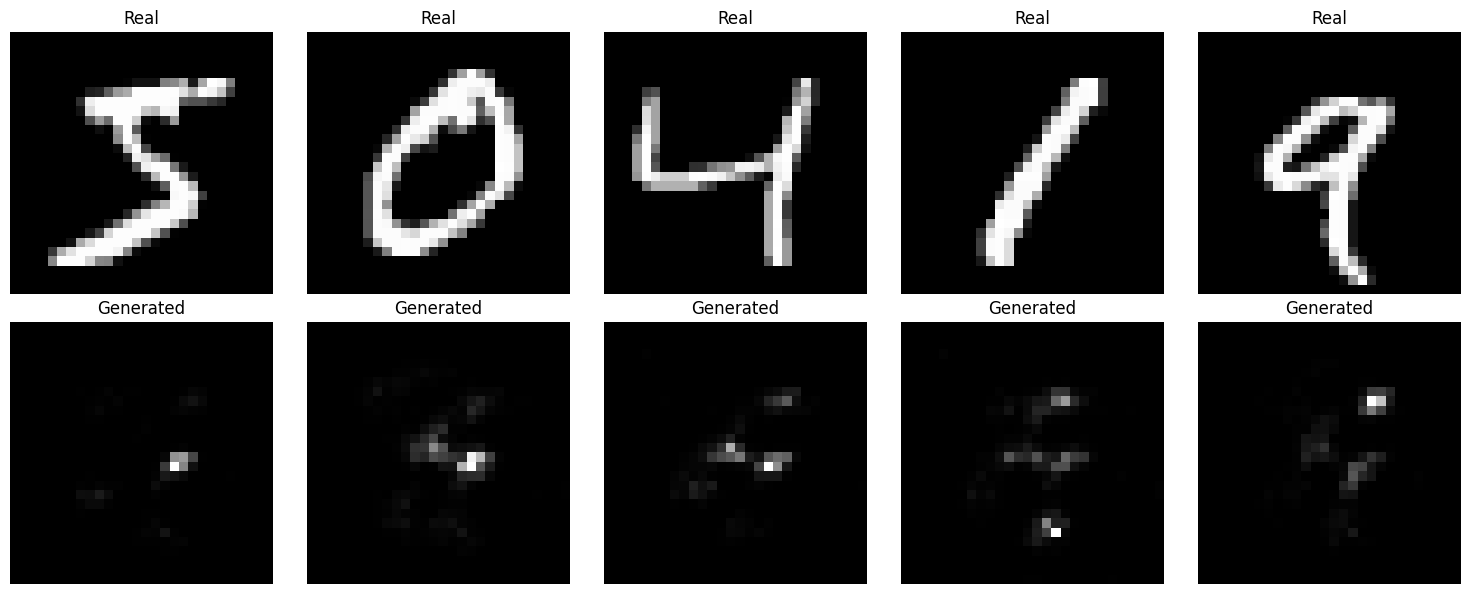

In [5]:
mean = 5.0
variance = 1.0
std_dev = np.sqrt(variance)
noise_vectors = np.random.normal(loc=mean, scale=std_dev, size=(5, latent_dim))

# Pass through decoder
generated_images = decoder.predict(noise_vectors)

# Show real and generated images side by side
plt.figure(figsize=(15, 6))
for i in range(5):
    # Real image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

    # Generated image
    plt.subplot(2, 5, i + 6)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.title("Generated")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your Denoising  Autoencoder.

#### Import Libraries and Load Data

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = np.reshape(x_train, (-1, 28, 28, 1))



#### Add Gaussian Noise to Training Data

In [8]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)


#### Define Denoising Autoencoder Architecture

In [9]:
latent_dim = 64

# Encoder
encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu')(x)
encoder = models.Model(encoder_input, latent, name='encoder')

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(28 * 28, activation='sigmoid')(x)
decoder_output = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(decoder_input, decoder_output, name='decoder')

# Denoising Autoencoder
dae_input = encoder_input
dae_output = decoder(encoder(dae_input))
dae = models.Model(dae_input, dae_output, name='denoising_autoencoder')

dae.compile(optimizer='adam', loss='binary_crossentropy')


#### Train the Denoising Autoencoder


In [10]:
dae.fit(x_train_noisy, x_train, epochs=5, batch_size=256, shuffle=True)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.3239
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1771
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1537
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1419
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1352


#### Generate Images from Noise Vectors

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


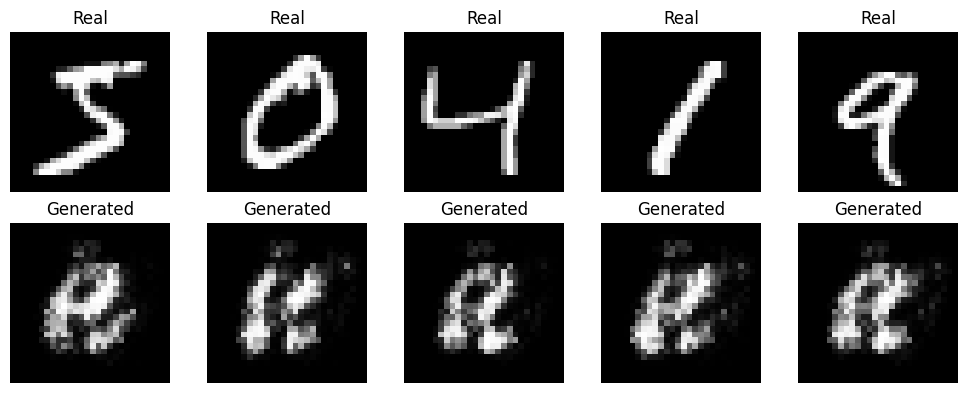

In [16]:
# Generate 5 noise vectors from N(mean=5, variance=1)
mean = 5.0
variance = 1.0
std_dev = np.sqrt(variance)
noise_vectors = np.random.normal(loc=mean, scale=std_dev, size=(5, latent_dim))

# Pass through decoder
generated_images = decoder.predict(noise_vectors)

# Show real and generated images side by side
plt.figure(figsize=(10, 4))
for i in range(5):
    # Real image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

    # Generated image
    plt.subplot(2, 5, i + 6)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.title("Generated")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Training and evaluating a Variational Autoencoder

#### Import Libraries and Load Data

In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))


#### Define VAE Components

In [44]:
# Sampling Layer (Reparameterization Trick)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
latent_dim = 2  # For easy visualization

encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_inputs)
x = layers.Dense(28 * 28, activation='sigmoid')(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(decoder_inputs, decoder_outputs, name='decoder')


#### VAE Model with Custom Loss

In [45]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def compile(self, optimizer):
        super(VAE, self).compile()
        self.optimizer = optimizer
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


#### Train the VAE

In [46]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(x_train, epochs=10, batch_size=256)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - kl_loss: 19.0447 - loss: 308.2922 - reconstruction_loss: 289.2474
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - kl_loss: 6.2899 - loss: 190.0788 - reconstruction_loss: 183.7889
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - kl_loss: 5.1618 - loss: 181.4139 - reconstruction_loss: 176.2521
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - kl_loss: 4.8548 - loss: 175.7560 - reconstruction_loss: 170.9012
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - kl_loss: 4.8354 - loss: 171.3097 - reconstruction_loss: 166.4743
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - kl_loss: 4.8780 - loss: 168.7773 - reconstruction_loss: 163.8993
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - kl_loss: 4.9170 - loss: 167.2908 - reconstruction_loss: 162.3738
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - kl_loss: 4.9676 - loss: 165.9827 - reconstruction_loss: 161.0151
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━

#### Evaluate and Visualize

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


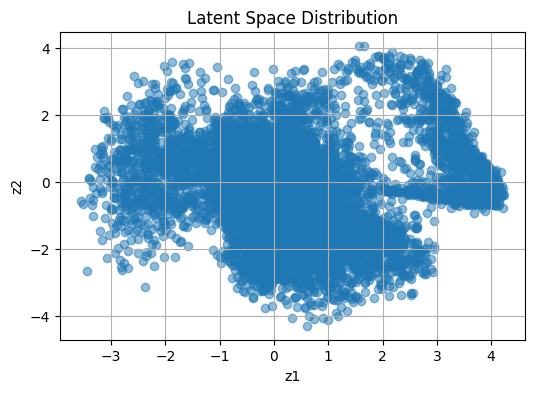

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


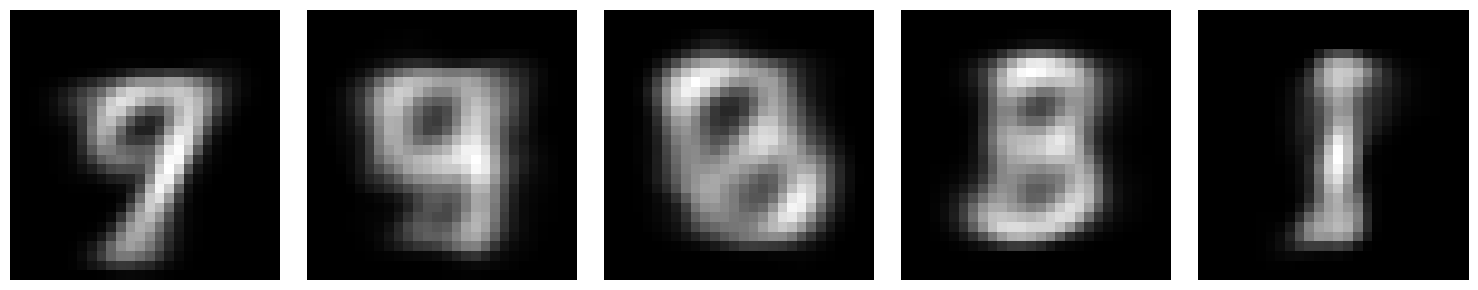

In [47]:
# Latent Space Visualization
z_mean, _, _ = encoder.predict(x_test)
plt.figure(figsize=(6, 4))
plt.scatter(z_mean[:, 0], z_mean[:, 1], alpha=0.5)
plt.title("Latent Space Distribution")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()

# Generate Images from Latent Space
# Sample 5 points from N(0, 1)
samples = np.random.normal(loc=0.0, scale=1.0, size=(5, latent_dim))
generated_images = decoder.predict(samples)

# Plot
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


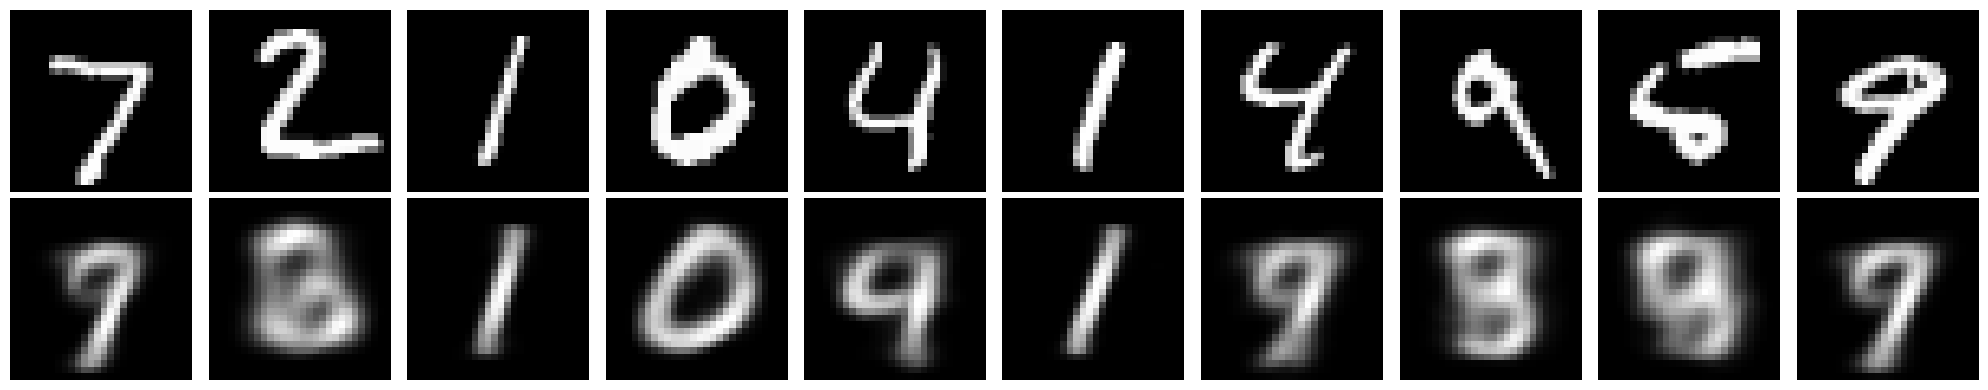

In [48]:
test_imgs = x_test[:10]
_, _, z_test = encoder.predict(test_imgs)
reconstructions = decoder.predict(z_test)

plt.figure(figsize=(20, 4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(test_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


## Generating five images passing five noise vectors/matrices drawn from a normal distribution with mean 5 and variance through the Decoder of your Variational  Autoencoder.

#### Generate Noise Vectors

In [49]:
# Latent dimension
latent_dim = 2

# Mean and variance
mean = 5.0
variance = 1.0
std_dev = np.sqrt(variance)

# Generate 5 noise vectors from N(mean=5, variance=1)
noise_vectors = np.random.normal(loc=mean, scale=std_dev, size=(5, latent_dim))


#### Pass Through Decoder

In [50]:
# Assuming your decoder is already defined and trained
generated_images = decoder.predict(noise_vectors)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


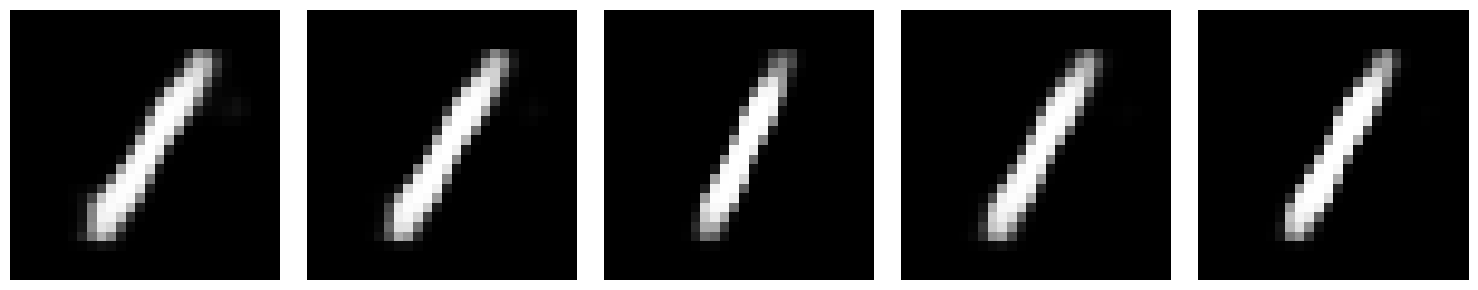

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()
